In [1]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "True"
sys.path.append(os.getcwd()+'/../')
import jax.numpy as jnp
import matplotlib.pyplot as plt
from CHIMERA.population.mass.paired import neural_density
from CHIMERA.population.mass import p_m1m2, p_m1, pdf_joint_and_marg

nn_config = dict(
    hidden_size=8, 
    depth=2,
    input_size=1,
)

model = neural_density(**nn_config, alpha = 2.5,
                       m_low=0.9245569825399548,  m_high=124.20678928592034,
                      bottomsmooth=0.08456654031744229, topsmooth=0.07731696292920931)
model

2026-08-13 11:18:33,410 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: True
W0813 11:18:34.359915 3359059 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
W0813 11:18:34.370160 3359011 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML library doesn't have required functions.
/tmp/ipykernel_3359011/722927793.py:15: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model = neural_density(**nn_config, alpha = 2.5,


neural_density(
  m_low=0.9245569825399548,
  m_high=124.20678928592034,
  m_grid=f64[500],
  norm_2d=f64[],
  keys=[
    'm_low',
    'm_high',
    'beta',
    'bottomsmooth',
    'topsmooth',
    'input_size',
    'hidden_size',
    'depth',
    'Ws',
    'bs'
  ],
  input_size=1,
  hidden_size=8,
  depth=2,
  Ws=[f64[8,1], f64[8,8], f64[1,8]],
  bs=[f64[8], f64[8]],
  beta=1.08,
  bottomsmooth=0.08456654031744229,
  topsmooth=0.07731696292920931,
  x_mean=weak_f64[],
  x_std=weak_f64[]
)

/leonardo/home/userexternal/mtagliaz/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:77: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return self.__class__(**fiducials)
/leonardo/home/userexternal/mtagliaz/softwares/CHIMERA/CHIMERA/population/mass/paired/base.py:77: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return self.__class__(**fiducials)


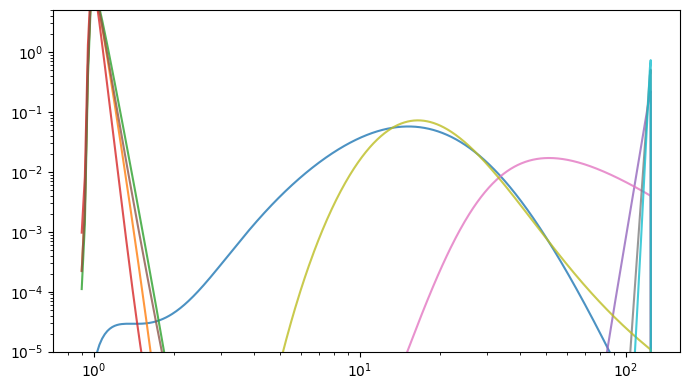

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from CHIMERA.utils import jax_distributions as dist
from CHIMERA.utils import emcee_utils as eu

def norm(loc, scale):
 return dist.Normal(loc=loc, scale=scale)

nn_config = dict(
    hidden_size=8, 
    depth=2,
    input_size=1,
)

priors = {
    **{f"nn_weight{i}": norm(loc=0., scale=5.) for i in range(nn_config['input_size'] * nn_config['hidden_size'])},
    **{f"nn_bias{i}": norm(loc=0., scale=2.5) for i in range(nn_config['hidden_size'])},
    **{f"nn_weight{i + nn_config['input_size'] * nn_config['hidden_size']}": norm(loc=0., scale=2.5) for i in range(nn_config['hidden_size']**2)},
    **{f"nn_bias{i + nn_config['hidden_size']}": norm(loc=0., scale=2.) for i in range(nn_config['hidden_size'])},
    **{f"nn_weight{i + nn_config['input_size'] * nn_config['hidden_size'] + nn_config['hidden_size']**2}": norm(loc=0., scale=2.) for i in range(nn_config['hidden_size'])},
}
param_keys = list(priors.keys())

# ---------------------------------------------------------------------------
# A few random realizations, overlaid on the marginal
# ---------------------------------------------------------------------------

n_realizations = 10
master_key = jax.random.PRNGKey(1)
keys = jax.random.split(master_key, n_realizations)

input_size = model.input_size
hidden_size = model.hidden_size
depth = model.depth

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

m1 = jnp.linspace(0.9,125,5000)

for i, key in enumerate(keys):
  subkeys = jax.random.split(key, len(param_keys))
  params = [priors[k].sample(subkeys[j]) for j, k in enumerate(param_keys)]
  hyperparams = eu.generate_dict(params, param_keys, nn_config=nn_config)
  model_rand = model.update(**hyperparams)

  pdf = p_m1(model_rand, m1)
  ax.plot(m1, pdf, alpha=0.8, label=f"draw {i}")
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.set_ylim(1e-5,5)  

fig.tight_layout()
plt.show()



In [3]:
m1 = jnp.linspace(0.5,150,5000)
m1g = jnp.array([m1 for _ in range(300)]).T
m2g = m1g*0.8

@jax.jit
def jitted_p_m1m2(model, m1, m2):
    return p_m1m2(model, m1, m2)

jitted_p_m1m2(model_rand, m1g, m2g)

%timeit -n 10 jitted_p_m1m2(model_rand, m1g, m2g).block_until_ready()

1.81 ms ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


1.43 ms ± 18.6 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


(1e-05, 3)

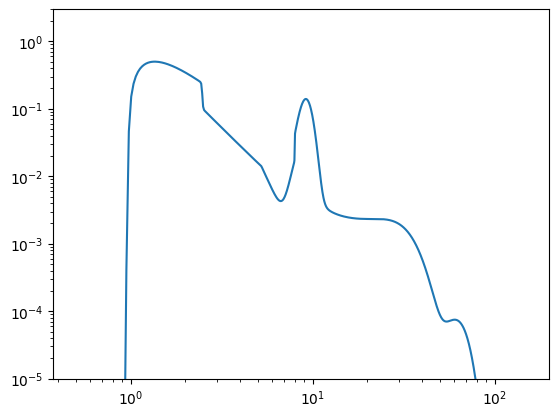

In [4]:
from CHIMERA.population.mass.paired import bpl_dip_three_peaks

model_2 = bpl_dip_three_peaks()
jitted_p_m1m2(model_2, m1g, m2g)
%timeit -n 10 jitted_p_m1m2(model_2, m1g, m2g).block_until_ready()

plt.plot(m1, p_m1(model_2, m1))
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-5,3)  

/tmp/ipykernel_3359011/3069479383.py:91: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  base_model = neural_density(


  step     0  MSE(log p) = 1.868e+01
  step  5000  MSE(log p) = 5.103e-01
  step 10000  MSE(log p) = 1.674e-01
  step 15000  MSE(log p) = 1.250e-01
  step 20000  MSE(log p) = 1.105e-01
  step 25000  MSE(log p) = 9.086e-02
  step 30000  MSE(log p) = 8.004e-02
  step 35000  MSE(log p) = 7.521e-02
  step 40000  MSE(log p) = 5.488e-02
  step 45000  MSE(log p) = 4.603e-02
  step 50000  MSE(log p) = 4.053e-02
  step 55000  MSE(log p) = 3.696e-02
  step 60000  MSE(log p) = 3.489e-02
  step 65000  MSE(log p) = 3.349e-02
  step 70000  MSE(log p) = 3.243e-02
  step 75000  MSE(log p) = 3.156e-02
  step 80000  MSE(log p) = 3.080e-02
  step 85000  MSE(log p) = 3.013e-02
  step 90000  MSE(log p) = 2.952e-02
  step 95000  MSE(log p) = 2.897e-02
  step 100000  MSE(log p) = 2.848e-02  (final)


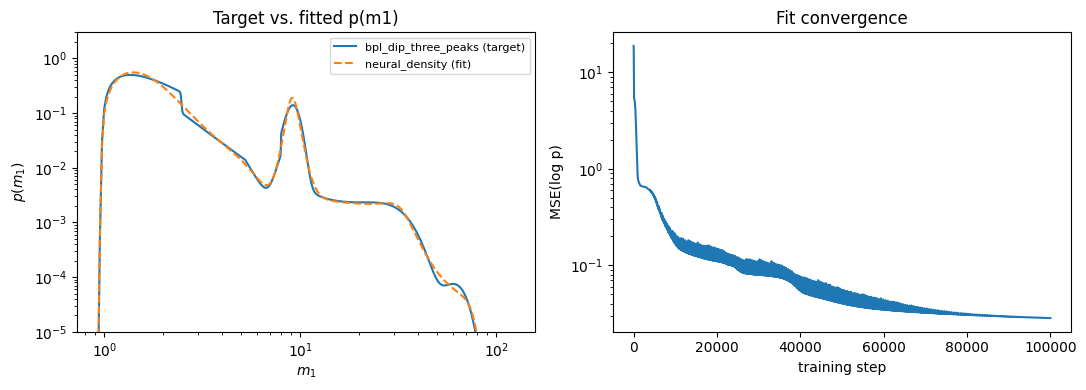

In [8]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

def fit_to_target_p_m1(target_model, base_model, n_grid=1000,
                        n_steps=5000, lr=3e-3, eps=1e-12, verbose=True):
  """Fit `base_model`'s Ws/bs so p_m1(base_model, .) matches
  p_m1(target_model, .), by MSE regression in log-space.
 
  Log-space (rather than linear) is used because p(m1) spans several
  orders of magnitude (dip + peaks); a linear MSE would be dominated by
  the tallest peak and effectively ignore the dip/tails, whereas
  log-space matches what you actually judge by eye on the usual log-y
  plot.
 
  Parameters
  ----------
  target_model : any CHIMERA paired mass model instance (e.g.
      `bpl_dip_three_peaks()`) whose p_m1 curve to reproduce.
  base_model : a `neural_density` instance providing the architecture
      and mass range to fit into, e.g.
      `neural_density(hidden_size=4, depth=2, m_low=..., m_high=...)`.
      Its current Ws/bs are just the optimizer's starting point.
  n_grid : number of log-spaced m1 points used for the regression.
  lr : peak learning rate. Adam uses a cosine decay from `lr` down to
      `0.01 * lr` over `n_steps`, rather than a fixed rate -- helps the
      loss actually settle near the end instead of bouncing around the
      minimum at full step size.
  eps : floor added before taking log, to avoid log(0) near the hard
      mass-range cutoff.
 
  Returns
  -------
  fitted_model : base_model with the fitted Ws/bs plugged in.
  losses : jnp.ndarray, per-step training loss.
  """

  m_low, m_high = base_model.m_low, base_model.m_high
  m_grid = jnp.logspace(
    jnp.log10(m_low), jnp.log10(m_high), n_grid,
  )

  target = p_m1(target_model, m_grid)
  log_target = jnp.log(target + eps)

  params0 = (base_model.Ws, base_model.bs) #

  def loss_fn(params):
    Ws, bs = params
    model = base_model.update(
      Ws=Ws,
      bs=bs,
    )
    pred = p_m1(model, m_grid)
    log_pred = jnp.log(pred + eps)
    return jnp.mean((log_pred - log_target) ** 2)

  lr_schedule = optax.cosine_decay_schedule(
    init_value=lr, decay_steps=n_steps, alpha=0.01,
  )
  optimizer = optax.adam(lr_schedule)
  opt_state = optimizer.init(params0)


  @jax.jit
  def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

  params = params0
  losses = []
  for i in range(n_steps):
    params, opt_state, loss = step(params, opt_state)
    losses.append(loss)
    if verbose and i % 5_000 == 0:
      print(f"  step {i:5d}  MSE(log p) = {loss:.3e}")

  Ws, bs = params
  fitted_model = base_model.update(Ws=Ws, bs=bs)
  if verbose:
    print(f"  step {n_steps:5d}  MSE(log p) = {losses[-1]:.3e}  (final)")

  return fitted_model, jnp.array(losses)


model_target = bpl_dip_three_peaks()

base_model = neural_density(
    hidden_size=8, depth=2,
    bottomsmooth=model_target.bottomsmooth, topsmooth=model_target.topsmooth,
    m_low=model_target.m_low, m_high=model_target.m_high,
)

fitted_model, losses = fit_to_target_p_m1(model_target, base_model, n_steps=100_000)

m1 = jnp.linspace(model_target.m_low, model_target.m_high, 5000)
pdf_target = p_m1(model_target, m1)
pdf_fit = p_m1(fitted_model, m1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(m1, pdf_target, label="bpl_dip_three_peaks (target)")
axes[0].plot(m1, pdf_fit, "--", label="neural_density (fit)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-5, 3)
axes[0].set(xlabel="$m_1$", ylabel="$p(m_1)$", title="Target vs. fitted p(m1)")
axes[0].legend(fontsize=8)

axes[1].plot(losses)
axes[1].set_yscale("log")
axes[1].set(xlabel="training step", ylabel="MSE(log p)", title="Fit convergence")

fig.tight_layout()
plt.show()

In [ ]:
#3.217e-02  (final)
# 2.857e-02  (final)

In [ ]:
for i in range(len(fitted_model.Ws)): 
    print(jnp.std(fitted_model.Ws[i]))

In [ ]:
for i in range(len(fitted_model.bs)): 
    print(jnp.std(fitted_model.bs[i]))

In [ ]:
fitted_model.alpha

In [ ]:
model_target